![a3uAqnb.png](https://i.imgur.com/a3uAqnb.png)

# Supervised Fine-Tuning (SFT)

Supervised Fine-Tuning (SFT) is the process of adapting a pretrained language model using labeled examples, typically instruction–response pairs, so that the model learns to produce the desired output for a given input.

- **2018 — Pre-train then Fine-Tune:** BERT popularized the paradigm of pretraining a language model and then fine-tuning it on supervised downstream tasks. ([Reference](https://arxiv.org/abs/1810.04805))

- **2021 — Instruction Tuning:** FLAN showed that fine-tuning language models on multiple tasks expressed as natural-language instructions improves generalization to unseen tasks. ([Reference](https://arxiv.org/abs/2109.01652))

- **2022 — Modern SFT for LLM Alignment:** InstructGPT used **Supervised Fine-Tuning (SFT)** on human-written instruction–response demonstrations before preference-based alignment with RLHF. ([Reference](https://arxiv.org/abs/2203.02155))



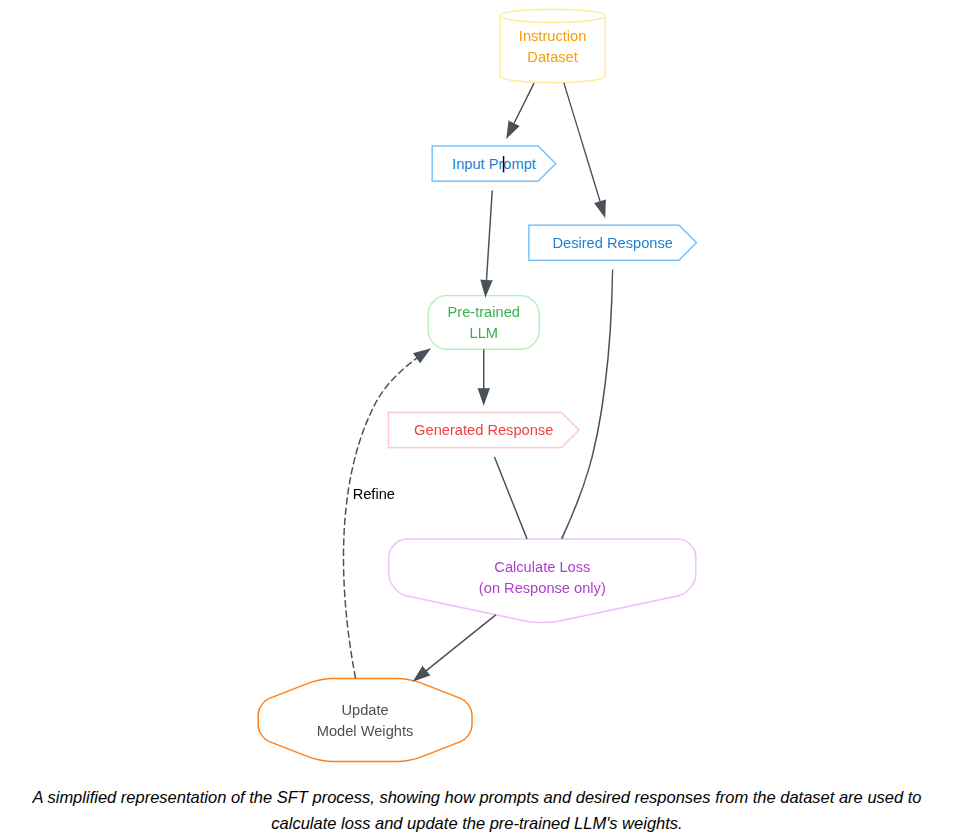



**Source:** [APXML — Introduction to Supervised Fine-Tuning](https://apxml.com/courses/how-to-build-a-large-language-model/chapter-25-supervised-fine-tuning-alignment/introduction-sft)

## Task: Natural Language to Structured JSON

In this lab, we will fine-tune a pretrained language model to convert a natural-language user request into a **structured JSON representation**.

The model must identify:

- **Intent** — what the user wants to do.
- **Slots** — important information mentioned in the request.

### Example

**Input**

> Set an alarm for 7 AM tomorrow.

**Target Output**

```json
{
  "intent": "alarm_set",
  "slots": {
    "time": "7 AM",
    "date": "tomorrow"
  }
}

## 1- Dataset

In [ ]:
from datasets import load_dataset

data = load_dataset(
    "AmazonScience/massive",
    "en-US",
    trust_remote_code=True,
)

dataset = data["train"]
validation_dataset = data["validation"]
test_dataset = data["test"]

print("Train:", len(dataset))
print("Validation:", len(validation_dataset))
print("Test:", len(test_dataset))

print(dataset)
print(dataset[0])

In [ ]:
import pandas as pd

df = dataset.to_pandas()

df["scenario_name"] = df["scenario"].apply(dataset.features["scenario"].int2str)

df["intent_name"] = df["intent"].apply(dataset.features["intent"].int2str)

print(f"Training examples : {len(df):,}")
print(f"Scenarios         : {df['scenario_name'].nunique()}")
print(f"Intents           : {df['intent_name'].nunique()}")

scenario_counts = (df["scenario_name"]
    .value_counts()
    .rename_axis("scenario")
    .reset_index(name="examples")
)
scenario_counts

In [ ]:
df.head(10)

#### 2- Frozen Qwen

In [ ]:
import torch
import re
import json
from tqdm.auto import tqdm

for param in model.parameters():
    param.requires_grad = False

model.eval()


def extract_slots(text):
    return {
        slot.strip(): value.strip()
        for slot, value in re.findall(
            r"\[([^:\]]+)\s*:\s*([^\]]+)\]",
            text
        )
    }


total = len(test_dataset)
valid_json = 0
correct_intent = 0
correct_slots = 0
correct_exact = 0


for example in tqdm(test_dataset, desc="Evaluating Frozen Qwen"):

    gold_intent = test_dataset.features["intent"].int2str(
        example["intent"]
    )

    gold_slots = extract_slots(
        example["annot_utt"]
    )

    prompt = f"""Convert the following user request into JSON.

Return JSON only using this format:
{{"intent": "...", "slots": {{}}}}

User request:
{example["utt"]}

JSON:
"""

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    generated = output[0][
        inputs["input_ids"].shape[1]:
    ]

    prediction = tokenizer.decode(
        generated,
        skip_special_tokens=True
    ).strip()

    try:
        pred = json.loads(prediction)

        valid_json += 1

        pred_intent = pred.get("intent", "")
        pred_slots = pred.get("slots", {})

        if pred_intent == gold_intent:
            correct_intent += 1

        if pred_slots == gold_slots:
            correct_slots += 1

        if (
            pred_intent == gold_intent
            and pred_slots == gold_slots
        ):
            correct_exact += 1

    except json.JSONDecodeError:
        pass

In [ ]:
print("\nFrozen Qwen Results")
print("=" * 40)

print(f"Test Examples        : {total}")



print(
    f"Intent Accuracy      : "
    f"{correct_intent / total * 100:.2f}%"
)

print(
    f"Slot Exact Accuracy  : "
    f"{correct_slots / total * 100:.2f}%"
)

print(
    f"Exact Match Accuracy : "
    f"{correct_exact / total * 100:.2f}%"
)

#### 3-SFT

In [ ]:
import re
import json
from transformers import (
    Trainer,
    TrainingArguments,
    DataCollatorForLanguageModeling,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

def extract_slots(text):
    return {
        slot.strip(): value.strip()
        for slot, value in re.findall(
            r"\[([^:\]]+)\s*:\s*([^\]]+)\]",
            text
        )
    }

def format_massive(batch):
    texts = []

    for utt, intent, annot in zip(
        batch["utt"],
        batch["intent"],
        batch["annot_utt"],
    ):
        intent_name = dataset.features["intent"].int2str(
            intent
        )

        answer = {
            "intent": intent_name,
            "slots": extract_slots(annot),
        }

        text = (
            "Convert the following user request into JSON.\n\n"
            f"User request:\n{utt}\n\n"
            "JSON:\n"
            f"{json.dumps(answer, ensure_ascii=False)}"
            f"{tokenizer.eos_token}"
        )

        texts.append(text)

    return tokenizer(
        texts,
        truncation=True,
        max_length=128,
    )

train_tokenized = dataset.map(
    format_massive,
    batched=True,
    remove_columns=dataset.column_names,
)

validation_tokenized = validation_dataset.map(
    format_massive,
    batched=True,
    remove_columns=validation_dataset.column_names,
)

for param in model.parameters():
    param.requires_grad = True

model.config.use_cache = False
model.gradient_checkpointing_enable()

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(
    f"Trainable percentage: "
    f"{100 * trainable_params / total_params:.2f}%"
)

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False,
)

training_args = TrainingArguments(
    output_dir="qwen_massive_sft",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-5,
    logging_steps=20,
    save_strategy="yes",
    report_to="none",
    bf16=True,
    gradient_checkpointing=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=validation_tokenized,
    data_collator=data_collator,
)

trainer.train()

#### 4- Evaluation

In [ ]:
import json
import torch
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

model.eval()
tokenizer.padding_side = "left"

def parse_json(text):
    try:
        return json.loads(text.strip())
    except:
        try:
            start = text.find("{")
            obj, _ = json.JSONDecoder().raw_decode(text[start:])
            return obj
        except:
            return None

def normalize_slots(slots):
    if not isinstance(slots, dict):
        return {}

    return {
        str(k).strip().lower(): str(v).strip().lower()
        for k, v in slots.items()
    }

results = []
batch_size = 8

for start in tqdm(range(0, len(test_dataset), batch_size)):

    batch = test_dataset[start:start + batch_size]

    prompts = [
        f"""Convert the following user request into JSON.

Return JSON only using this format:
{{"intent": "...", "slots": {{}}}}

User request:
{utt}

JSON:
"""
        for utt in batch["utt"]
    ]

    inputs = tokenizer(
        prompts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128
    ).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=80,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id
        )

    generated = outputs[
        :,
        inputs["input_ids"].shape[1]:
    ]

    predictions = tokenizer.batch_decode(
        generated,
        skip_special_tokens=True
    )

    for i, prediction in enumerate(predictions):

        gold_intent = (
            test_dataset.features["intent"]
            .int2str(batch["intent"][i])
        )

        gold_slots = normalize_slots(
            extract_slots(batch["annot_utt"][i])
        )

        parsed = parse_json(prediction)

        pred_intent = ""
        pred_slots = {}

        if isinstance(parsed, dict):
            pred_intent = str(
                parsed.get("intent", "")
            ).strip().lower()

            pred_slots = normalize_slots(
                parsed.get("slots", {})
            )

        results.append({
            "gold_intent": gold_intent.lower(),
            "pred_intent": pred_intent,
            "gold_slots": gold_slots,
            "pred_slots": pred_slots,
            "valid_json": isinstance(parsed, dict)
        })

total = len(results)

valid_json_rate = sum(
    r["valid_json"] for r in results
) / total

intent_accuracy = sum(
    r["gold_intent"] == r["pred_intent"]
    for r in results
) / total

tp = 0
fp = 0
fn = 0
exact = 0

for r in results:

    gold_pairs = set(r["gold_slots"].items())
    pred_pairs = set(r["pred_slots"].items())

    tp += len(gold_pairs & pred_pairs)
    fp += len(pred_pairs - gold_pairs)
    fn += len(gold_pairs - pred_pairs)

    if (
        r["gold_intent"] == r["pred_intent"]
        and r["gold_slots"] == r["pred_slots"]
    ):
        exact += 1

precision = tp / (tp + fp) if tp + fp else 0
recall = tp / (tp + fn) if tp + fn else 0

slot_f1 = (
    2 * precision * recall / (precision + recall)
    if precision + recall
    else 0
)

exact_match = exact / total

metrics = {
    "Valid JSON": valid_json_rate * 100,
    "Intent Accuracy": intent_accuracy * 100,
    "Slot F1": slot_f1 * 100,
    "Exact Match": exact_match * 100
}

print("SFT Final Results")
print("-" * 30)

for name, value in metrics.items():
    print(f"{name:18}: {value:.2f}%")



In [ ]:

frozen_metrics = {
    "Intent Accuracy": correct_intent / total * 100,
    "Slot F1": slot_f1 * 100,
    "Exact Match": correct_exact / total * 100,
}


ft_metrics_plot = {
    "Intent Accuracy": metrics["Intent Accuracy"],
    "Slot F1": metrics["Slot F1"],
    "Exact Match": metrics["Exact Match"],
}

df = pd.DataFrame({
    "Frozen": frozen_metrics,
    "Full FT": ft_metrics_plot
})

df.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Score (%)")
plt.title("Frozen Qwen vs Full Fine-Tuning")
plt.xticks(rotation=20)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Prepared by :Lama